In [85]:
# %pip install -q ipywidgets
# %pip install ipympl
# %pip install matplotlib 
# %matplotlib widget

In [86]:

%pip install --upgrade illuminator

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [87]:
%pip show illuminator

Name: illuminator
Version: 3.1b0
Summary: A development toolkit for simulating energy systems
Home-page: 
Author: Jort Groen, Despoina Kassandra Georgiadi, Josip Grguric, Yasel Quintero Lares, Joan Pijpker, Manuel Garcia Alvarez, Mano Rom
Author-email: 
License: GNU LESSER GENERAL PUBLIC LICENSE
                       Version 2.1, February 1999

 Copyright (C) 1991, 1999 Free Software Foundation, Inc.
 51 Franklin Street, Fifth Floor, Boston, MA  02110-1301  USA
 Everyone is permitted to copy and distribute verbatim copies
 of this license document, but changing it is not allowed.

                            Preamble

  The licenses for most software are designed to take away your
freedom to share and change it.  By contrast, the GNU General Public
Licenses are intended to guarantee your freedom to share and change
free software--to make sure the software is free for all its users.

  This license, the Lesser General Public License, applies to some
specially designated software packag

In [88]:
import platform
print(platform. python_version())

3.11.9


In [89]:
from illuminator.engine import Simulation
import pandas as pd
import nest_asyncio
nest_asyncio.apply()
from illuminator.builder import IlluminatorModel, ModelConstructor


# TODO: When done move everything to one helper py script file

from energy_dashboard_function import run_energy_dashboard
from combined_analysis_plots import plot_combined_analysis 
from electricity_cost_calculator import calculate_electricity_cost
from complete_co2_workflow import align_dates_and_calculate_co2


# TODO
adjust time step to quarters of a year or monthly based on EH contract 
add corridor param

In [90]:
import numpy as np
import ast
from illuminator.builder import ModelConstructor

class JusticeAgentController(ModelConstructor):
    """
    Justice Agent Controller for managing energy reciprocity.
    Analyzes global energy state (Gini, Usage Rate) and outputs 
    recommendations for each household based on per-house lists.
    """

    parameters = {
        'houses': 2,
        'alpha': 0.1,  # Production incentive coefficient
        'beta': 0.1,   # Consumption reduction coefficient
    }
    
    inputs = {
        'consumption': [], # Expecting a list from New_House_Type
        'production': []   # Expecting a list from New_House_Type
    }
    
    outputs = {
        'recommendations': [], # List of [action_name, [i_econ, i_soc, i_eco], coeff]
        'usage_rate': 0,
        'reciprocity_index': 0
    }

    def __init__(self, **kwargs) -> None:
        super().__init__(**kwargs)
        # Maintaining exact structure as requested
        self.houses = self._model.parameters.get('houses', 2)
        self.alpha = self._model.parameters.get('alpha', 0.1)
        self.beta = self._model.parameters.get('beta', 0.1)
        
    # def step(self, time: int, inputs: dict = None, max_advance: int = 900) -> int:
    #     # 1. Properly aggregate consumption from all sending sources
    #     # inputs['consumption'] usually looks like: {'House_0': 12.5, 'House_1': 8.0, ...}
    #     cons_data = inputs.get('consumption', {})
    #     if isinstance(cons_data, dict) and len(cons_data) > 0:
    #         # Sort by key to ensure House 0 is always index 0, House 1 is index 1, etc.
    #         cons_in = [float(cons_data[k]) for k in sorted(cons_data.keys())]
    #     else:
    #         cons_in = [0.0] * self.houses

    #     # 2. Properly aggregate production
    #     prod_data = inputs.get('production', {})
    #     if isinstance(prod_data, dict) and len(prod_data) > 0:
    #         prod_in = [float(prod_data[k]) for k in sorted(prod_data.keys())]
    #     else:
    #         prod_in = [0.0] * self.houses

    #     # DEBUG: Let's see what the lists actually look like before logic
    #     print(f"DEBUG STEP {time}: Cons List: {cons_in} | Prod List: {prod_in}")

    #     # 3. Calculate Justice
    #     results = self.calculate_justice_logic(cons_in, prod_in)
        
    #     # 4. Set outputs
    #     self.set_outputs(results)

    #     return time + self._model.time_step_size

    def step(self, time: int, inputs: dict = None, max_advance: int = 900) -> int:
        # 1. Strip the outer 'time-based_0' wrapper if it exists
        # This is the "Aha!" moment from your logs
        actual_inputs = inputs.get('time-based_0', inputs) 
        
        print(f"\n[DEBUG STEP {time}] Actual Inputs: {actual_inputs.keys()}")

        # 2. Extract Consumption
        cons_data = actual_inputs.get('consumption', {})
        cons_in = self._unpack_mosaik_data(cons_data)
        
        # 3. Extract Production
        prod_data = actual_inputs.get('production', {})
        prod_in = self._unpack_mosaik_data(prod_data)

        # 4. Check and execute
        if not cons_in or not prod_in:
            print(f"  >> ERROR: Still no data. Raw structure: {actual_inputs}")
            return time + self._model.time_step_size

        results = self.calculate_justice_logic(cons_in, prod_in)
        self.set_outputs(results)

        return time + self._model.time_step_size

    def _unpack_mosaik_data(self, attr_dict):
        """Helper to reach through Neighborhood_A-0... -> 'value'"""
        if not attr_dict:
            return []
        
        try:
            # We get the first entity (Neighborhood_A)
            entity_id = list(attr_dict.keys())[0]
            # Your log shows: {'Neighborhood_A...': {'message_origin': 'output', 'value': [...]}}
            # So we need to access ['value']
            data_packet = attr_dict[entity_id]
            
            if isinstance(data_packet, dict) and 'value' in data_packet:
                return data_packet['value']
            return data_packet # Fallback if it's already the list
        except Exception as e:
            print(f"  >> Unpack Error: {e}")
            return []
    

    def _parse_list(self, data):
        """Helper to ensure input is a clean list of floats of length self.houses."""
        # Handle string serialization if it occurs
        if isinstance(data, str):
            try:
                data = ast.literal_eval(data)
            except:
                return [0.0] * self.houses
        
        # If it's just a single number (common at step 0), expand it to a list
        if isinstance(data, (int, float)):
            return [float(data)] * self.houses
            
        # Ensure the list matches the number of houses
        if isinstance(data, list):
            if len(data) == self.houses:
                return [float(x) for x in data]
            else:
                # Pad or trim to match house count
                return (list(data) + [0.0] * self.houses)[:self.houses]
        
        return [0.0] * self.houses

    def calculate_gini_index(self, cons_list, prod_list):
        """1 - Gini coefficient of [|prod_i - cons_i|]"""
        diffs = [abs(p - c) for p, c in zip(prod_list, cons_list)]
        n = len(diffs)
        # If all houses are perfectly balanced (diff=0), reciprocity is 1.0
        if n < 2 or sum(diffs) == 0: 
            return 1.0
        
        diffs = np.sort(diffs)
        index = np.arange(1, n + 1)
        gini = (np.sum((2 * index - n - 1) * diffs)) / (n * np.sum(diffs))
        return float(1 - gini)

    # def get_recommendation_packet(self, target_group, dev_cons, dev_prod):
    #     """
    #     Maps deviation and target group to specific incentive weights.
    #     """
    #     res = ["No action", [0, 0, 0], 0]

    #     if target_group == "receiver":
    #         if dev_cons > 0.35:           res = ["Reduce consumption", [1.0, 0, 1.0], 1.0]
    #         elif 0.15 < dev_cons:         res = ["Receive Penalty", [1.0, 1.0, 1.0], 0.5]
    #         elif 0 < dev_cons:            res = ["Flexible Consumption", [0, 1.0, 1.0], 0.25]
    #         elif 0 < dev_prod <= 0.15:    res = ["Subsidy for PV", [1.0, 1.0, 0], 0.5]
    #         elif 0.15 < dev_prod <= 0.35: res = ["Expand PV", [0, 1.0, 1.0], 0.25]
    #         elif dev_prod > 0.35:         res = ["Installing PV", [0, 1.0, 1.0], 1.0]
            
    #     elif target_group == "balanced":
    #         if dev_cons > 0.35:           res = ["Reduce consumption", [0, 0.5, 0.5], 1.0]
    #         elif 0.15 < dev_cons:         res = ["Receive Penalty", [1.0, 0.5, 0.5], 0.5]
    #         elif 0 < dev_cons:            res = ["Flexible Consumption", [0, 0.5, 0.5], 0.25]
    #         elif 0 < dev_prod <= 0.15:    res = ["Subsidy for PV", [1.0, 0.5, 0.5], 0.5]
    #         elif 0.15 < dev_prod <= 0.35: res = ["Expand PV", [0, 0.5, 0.5], 0.25]
    #         elif dev_prod > 0.35:         res = ["Installing PV", [0, 0.5, 0.5], 1.0]

    #     elif target_group == "contributor":
    #         if dev_cons > 0.35:           res = ["Reduce consumption", [0, 0.5, 0], 1.0]
    #         elif 0.15 < dev_cons:         res = ["Receive Penalty", [0, 0.5, 0], 0.5]
    #         elif 0 < dev_cons:            res = ["Flexible Consumption", [0, 0.5, 0], 0.25]
    #         elif 0 < dev_prod <= 0.15:    res = ["Subsidy for PV", [0, 0.5, 0.5], 0.5]
    #         elif 0.15 < dev_prod <= 0.35: res = ["Expand PV", [0, 0.5, 0.5], 0.25]
    #         elif dev_prod > 0.35:         res = ["Installing PV", [0, 0.5, 0.5], 1.0]

    #     return res

    def get_recommendation_packet(self, target_group, dev_cons, dev_prod, house_id):
        """
        Maps deviation and target group to specific incentive weights.
        """
        res = ["No action", [0, 0, 0], 0]
        
        # Debugging Print: See exactly what the packet receives
        print(f"House {house_id} | Group: {target_group} | d_cons: {dev_cons:.2f} | d_prod: {dev_prod:.2f}")

        # PRIORITY 1: High Consumption (Outliers above 35% of mean)
        if dev_cons > 0.35:
            print(f"  >> Triggered High Cons for House {house_id}")
            if target_group == "receiver":
                return ["Reduce consumption", [1.0, 0.2, 1.0], 1.0]
            else:
                return ["Reduce consumption", [0.5, 0.5, 1.0], 1.0]

        # PRIORITY 2: Low Production (Negative Deviations)
        if dev_prod < -0.35:
            print(f"  >> Triggered Low Prod for House {house_id}")
            if target_group == "receiver":
                return ["Installing PV", [1.0, 0.5, 1.0], 1.0]
            else:
                return ["Installing PV", [0.5, 1.0, 0.5], 1.0]
                
        elif dev_prod < -0.15:
            print(f"  >> Triggered PV Subsidy for House {house_id}")
            return ["Subsidy for PV", [1.0, 0.8, 0.2], 0.5]

        # PRIORITY 3: Moderate Consumption issues (15% to 35% above mean)
        if 0.15 < dev_cons <= 0.35:
            print(f"  >> Triggered Penalty for House {house_id}")
            if target_group == "receiver":
                return ["Receive Penalty", [1.0, 1.0, 1.0], 0.5]
            else:
                return ["Receive Penalty", [0.5, 0.5, 0.5], 0.5]

        # PRIORITY 4: Minor adjustments
        if 0 < dev_cons <= 0.15:
            print(f"  >> Triggered Flex Cons for House {house_id}")
            return ["Flexible Consumption", [0.2, 1.0, 1.0], 0.25]
        
        if 0 < dev_prod <= 0.15:
            print(f"  >> Triggered Expand PV for House {house_id}")
            return ["Expand PV", [0.2, 1.0, 1.0], 0.25]

        print(f"  >> Result: NO ACTION for House {house_id}")
        return res

    def calculate_justice_logic(self, cons_list, prod_list) -> dict:
        sum_cons = sum(cons_list)
        sum_prod = sum(prod_list)
        m_cons = sum_cons / self.houses if self.houses > 0 else 0
        m_prod = sum_prod / self.houses if self.houses > 0 else 0
        
        usage_rate = float(sum_cons / sum_prod if sum_prod != 0 else 999)
        recip_idx = self.calculate_gini_index(cons_list, prod_list)
        
        print(f"\n--- Justice Step: Mean Cons: {m_cons:.2f}, Mean Prod: {m_prod:.2f}, Usage: {usage_rate:.2f} ---")
        
        recommendations = []

        for i in range(self.houses):
            p, c = prod_list[i], cons_list[i]
            d_cons = (c - m_cons) / m_cons if m_cons > 0 else 0
            d_prod = (p - m_prod) / m_prod if m_prod > 0 else 0
            
            # Simplified grouping to ensure we ALWAYS have a group
            if p < c:    target_group = "receiver"
            elif p > c:  target_group = "contributor"
            else:        target_group = "balanced"

            # Run recommendation
            rec = self.get_recommendation_packet(target_group, d_cons, d_prod, i)
            recommendations.append(rec)

        return {
            'recommendations': recommendations,
            'usage_rate': usage_rate,
            'reciprocity_index': recip_idx
        }

In [ ]:
import ast
from illuminator.builder import ModelConstructor

class New_House_Type(ModelConstructor):
    parameters = {
        'houses': 5,
        'alphas': [0.1, 0.5, 0.2, 0.8, 0.3],
        'betas': [0.05, 0.2, 0.1, 0.4, 0.1],
        'consumption': [2.5, 1.2, 3.8, 0.5, 2.0],
        'production': [0.8, 2.5, 0.0, 1.5, 0.5],
        'incentive_weights': [[0.5, 0.2, 0.3], [0.1, 0.1, 0.8], [0.5, 0.5, 0.0], [0.2, 0.2, 0.6], [0.4, 0.4, 0.2]], 
        'decision_threshold': 0.5 
    }
    
    inputs = {
        'recommendations': [] 
    }
    
    outputs = {
        'sum_load_dem': 0,
        'sum_consumption': 0,
        'sum_production': 0,
        'consumption': [], 
        'production': []   
    }

    def __init__(self, **kwargs) -> None:
        super().__init__(**kwargs)
        params = self._model.parameters
        
        self.houses = params.get('houses', 5)
        self.alphas = params.get('alphas', [0.1] * self.houses)
        self.betas = params.get('betas', [0.1] * self.houses)
        
        # CRITICAL: Use list() to create a deep copy so we can modify it 
        # independently over time without referencing the static YAML params.
        self.base_consumption = list(params.get('consumption', [0.0] * self.houses))
        self.base_production = list(params.get('production', [0.0] * self.houses))
        
        self.incentive_weights = params.get('incentive_weights', [[1/3, 1/3, 1/3]] * self.houses)
        self.threshold = params.get('decision_threshold', 0.5)

        print(f"DEBUG INIT: Cons check: {self.base_consumption}")

    def step(self, time: int, inputs: dict = None, max_advance: int = 900) -> int:
        actual_inputs = inputs.get('time-based_0', inputs)
        
        # Extract recommendations from the mosaik-style input dictionary
        recs_dict = actual_inputs.get('recommendations', {})
        recs_list = []
        
        if recs_dict:
            # mosaik sends dicts keyed by entity ID. We grab the list from the first one.
            recs_list = list(recs_dict.values())[0]
            print(f"[HOUSE STEP {time}] Received {len(recs_list)} recommendations.")
        else:
            print(f"[HOUSE STEP {time}] NO recommendations found in inputs!")

        # Process the dynamics and set outputs for the collector
        results = self.calculate_household_dynamics(recs_list)
        self.set_outputs(results)

        return time + self._model.time_step_size

    def calculate_household_dynamics(self, recommendations) -> dict:
        individual_dem = []
        
        # --- FIXED EXTRACTION LOGIC ---
        if isinstance(recommendations, dict):
            # We now know specifically to look for the 'value' key
            if 'value' in recommendations:
                recommendations = recommendations['value']
            else:
                # Fallback in case mosaik nesting changes
                recommendations = next(iter(recommendations.values()))
        
        # If it's STILL a string (like 'output'), we know we grabbed the wrong key
        if isinstance(recommendations, str):
             print(f"[CRITICAL] Grabbed a string instead of a list: {recommendations}")
             recommendations = []
             
        if not isinstance(recommendations, list):
            recommendations = []
        # -------------------------------

        print(f"\n--- Processing {len(recommendations)} Recommendations ---")

        for i in range(self.houses):
            individual_dem.append(self.base_consumption[i])

            if i < len(recommendations):
                rec = recommendations[i]
                
                if isinstance(rec, list) and len(rec) == 3:
                    action_name, action_incentives, action_coeff = rec
                    
                    if action_name != "No action":
                        house_weights = self.incentive_weights[i]
                        score = sum(w * s for w, s in zip(house_weights, action_incentives))
                        
                        print(f"  House {i} | {action_name} | Score: {score:.2f} vs Thresh: {self.threshold}")

                        if score >= self.threshold:
                            name_lower = action_name.lower()
                            
                            # Match keywords for consumption reduction
                            if any(kw in name_lower for kw in ["cons", "reduce", "penalty"]):
                                old_val = self.base_consumption[i]
                                self.base_consumption[i] *= (1 - (action_coeff * self.alphas[i]))
                                print(f"    >>> ACCEPTED: {old_val:.2f} -> {self.base_consumption[i]:.2f}")
                            
                            # Match keywords for PV/Production
                            elif any(kw in name_lower for kw in ["pv", "install", "subsidy"]):
                                old_val = self.base_production[i]
                                self.base_production[i] *= (1 + (action_coeff * self.betas[i]))
                                print(f"    >>> ACCEPTED: Prod {old_val:.2f} -> {self.base_production[i]:.2f}")
                        else:
                            print(f"    xxx REJECTED: Score {score:.2f} too low.")
                    else:
                        print(f"  House {i} | Agent suggested 'No action'")
            
            # Final persistence
            self.base_consumption[i] = round(float(self.base_consumption[i]), 4)
            self.base_production[i] = round(float(self.base_production[i]), 4)

        return {
            'sum_load_dem': round(sum(individual_dem), 2),
            'sum_consumption': round(sum(self.base_consumption), 2),
            'sum_production': round(sum(self.base_production), 2),
            'consumption': list(self.base_consumption),
            'production': list(self.base_production)
        }

In [92]:
from illuminator.models.import_custom_model import import_custom_model
# Specifically ensure New_House_Type is the one it finds
import_custom_model(New_House_Type)
import_custom_model(JusticeAgentController)

In [93]:
# %%capture
# CONFIG_FILE = 'data\dummy.yaml''
CONFIG_FILE = 'data\IDE_test.yaml'
simulation = Simulation(CONFIG_FILE)
simulation.run()


        ____                              _ _
       /    \                            (_) |
  ____/      \  _ __ ___   ___  ___  __ _ _| | __
 /    \      / | '_ ` _ \ / _ \/ __|/ _` | | |/ /
/      \____/  | | | | | | (_) \__ \ (_| | |   <
\      /    \  |_| |_| |_|\___/|___/\__,_|_|_|\_\
 \____/      \____
 /    \      /    \     mosaik: 3.6.0
/      \____/      \       API: 3.0.14
\      /    \      /    Python: 3.11.9
 \____/      \____/         OS: Windows-10-10.0.26100-SP0
      \      /            Docs: https://mosaik.readthedocs.io/en/3.6.0/
       \____/     Get in touch: https://github.com/orgs/OFFIS-mosaik/discussions

2026-05-07 15:48:36.482 | INFO     | mosaik.async_scenario:start:508 - Starting 'Justice_Controller-0' (based on starter 'Justice_Controller')
2026-05-07 15:48:36.486 | INFO     | mosaik.async_scenario:start:508 - Starting 'Neighborhood_A-0' (based on starter 'Neighborhood_A')
2026-05-07 15:48:36.490 | INFO     | mosaik.async_scenario:start:508 - Starting 'C

2026-05-07 15:48:36.493 | INFO     | mosaik.async_scenario:run:1008 - Starting simulation.


c:\Users\dgeorgiadi\Documents\Illuminator_edu\educational_material\tutorials\energy_hubs\Energy HUB
running extra init
{'Justice_Controller': [Entity(full_id='Justice_Controller-0.time-based_0', model_mock=<mosaik.async_scenario.AsyncModelMock object at 0x00000259A62B9690>, children=[])]}
DEBUG INIT: Cons check: [12.5, 1.2, 9.8, 0.5, 2.0]
running extra init
{'Justice_Controller': [Entity(full_id='Justice_Controller-0.time-based_0', model_mock=<mosaik.async_scenario.AsyncModelMock object at 0x00000259A62B9690>, children=[])], 'Neighborhood_A': [Entity(full_id='Neighborhood_A-0.time-based_0', model_mock=<mosaik.async_scenario.AsyncModelMock object at 0x00000259A62FEA10>, children=[])]}
running extra init
{'Justice_Controller': [Entity(full_id='Justice_Controller-0.time-based_0', model_mock=<mosaik.async_scenario.AsyncModelMock object at 0x00000259A62B9690>, children=[])], 'Neighborhood_A': [Entity(full_id='Neighborhood_A-0.time-based_0', model_mock=<mosaik.async_scenario.AsyncModelMock o

 26%|██▋       | 25/95 [00:00<00:00, 249.54steps/s]

[HOUSE STEP 0] Received 2 recommendations.

[DEBUG DYNAMICS] Incoming type: <class 'dict'>
[DEBUG DYNAMICS] Raw data: {'message_origin': 'output', 'value': []}
[DEBUG DYNAMICS] Keys found: ['message_origin', 'value']
[DEBUG DYNAMICS] Extracted from dict. New length: 6
[DEBUG DYNAMICS] WARNING: Data is still not a list. Type: <class 'str'>
  House 0 | Note: No recommendation provided for this index.
  House 1 | Note: No recommendation provided for this index.
  House 2 | Note: No recommendation provided for this index.
  House 3 | Note: No recommendation provided for this index.
  House 4 | Note: No recommendation provided for this index.

[DEBUG STEP 0] Actual Inputs: dict_keys(['consumption', 'production'])

--- Justice Step: Mean Cons: 5.20, Mean Prod: 1.66, Usage: 3.13 ---
House 0 | Group: receiver | d_cons: 1.40 | d_prod: -0.52
  >> Triggered High Cons for House 0
House 1 | Group: contributor | d_cons: -0.77 | d_prod: 0.51
  >> Result: NO ACTION for House 1
House 2 | Group: receive

 68%|██████▊   | 65/95 [00:00<00:00, 331.77steps/s]

[HOUSE STEP 60] Received 2 recommendations.

[DEBUG DYNAMICS] Incoming type: <class 'dict'>
[DEBUG DYNAMICS] Raw data: {'message_origin': 'output', 'value': [['Reduce consumption', [1.0, 0.2, 1.0], 1.0], ['No action', [0, 0, 0], 0], ['Reduce consumption', [1.0, 0.2, 1.0], 1.0], ['No action', [0, 0, 0], 0], ['Installing PV', [1.0, 0.5, 1.0], 1.0]]}
[DEBUG DYNAMICS] Keys found: ['message_origin', 'value']
[DEBUG DYNAMICS] Extracted from dict. New length: 6
[DEBUG DYNAMICS] WARNING: Data is still not a list. Type: <class 'str'>
  House 0 | Note: No recommendation provided for this index.
  House 1 | Note: No recommendation provided for this index.
  House 2 | Note: No recommendation provided for this index.
  House 3 | Note: No recommendation provided for this index.
  House 4 | Note: No recommendation provided for this index.

[DEBUG STEP 60] Actual Inputs: dict_keys(['consumption', 'production'])

--- Justice Step: Mean Cons: 5.20, Mean Prod: 1.66, Usage: 3.13 ---
House 0 | Group: recei

100%|██████████| 95/95 [00:00<00:00, 250.56steps/s]
2026-05-07 15:48:36.880 | INFO     | mosaik.async_scenario:run:1045 - Simulation finished successfully.


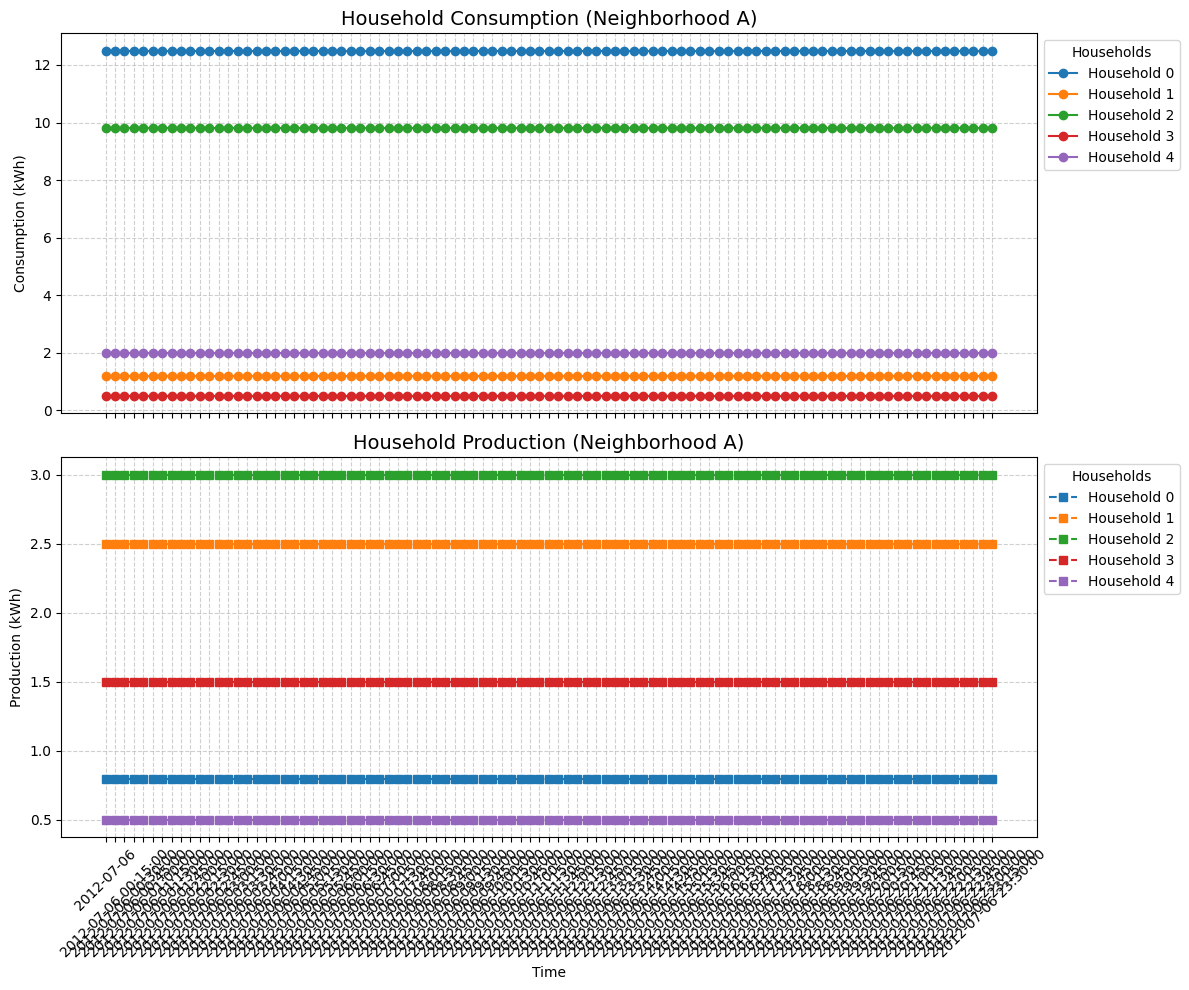

In [48]:
import pandas as pd
import matplotlib.pyplot as plt
import ast

# 1. Load the data
df = pd.read_csv('out_justice_test.csv')

# 2. Convert strings of lists into actual Python lists
df['Neighborhood_A.consumption'] = df['Neighborhood_A.consumption'].apply(ast.literal_eval)
df['Neighborhood_A.production'] = df['Neighborhood_A.production'].apply(ast.literal_eval)

# 3. Expand the lists into separate columns for plotting
# This creates columns like Cons_0, Cons_1, etc.
cons_expanded = pd.DataFrame(df['Neighborhood_A.consumption'].tolist(), index=df.index)
prod_expanded = pd.DataFrame(df['Neighborhood_A.production'].tolist(), index=df.index)

# 4. Plotting
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# Plot Consumption
for i in range(cons_expanded.shape[1]):
    ax1.plot(df['date'], cons_expanded[i], marker='o', label=f'Household {i}')

ax1.set_title('Household Consumption (Neighborhood A)', fontsize=14)
ax1.set_ylabel('Consumption (kWh)')
ax1.legend(title="Households", loc='upper left', bbox_to_anchor=(1, 1))
ax1.grid(True, linestyle='--', alpha=0.6)

# Plot Production
for i in range(prod_expanded.shape[1]):
    ax2.plot(df['date'], prod_expanded[i], marker='s', linestyle='--', label=f'Household {i}')

ax2.set_title('Household Production (Neighborhood A)', fontsize=14)
ax2.set_ylabel('Production (kWh)')
ax2.set_xlabel('Time')
ax2.legend(title="Households", loc='upper left', bbox_to_anchor=(1, 1))
ax2.grid(True, linestyle='--', alpha=0.6)

# Improve x-axis readability
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# from illuminator.builder import ModelConstructor

# class New_House_Type(ModelConstructor):
#     """
#     New Household Load model for IDE's Justice Agent (Tutorial 5).
#     Calculates individual and aggregate consumption/production and handles 
#     weighted decision-making for recommended actions.
#     """

#     parameters = {
#         'houses': 2,  
#         'incentive_weights': [[0.2, 0.3, 0.5], [0.5, 0.5, 0.0]], 
#         'input_type': 'energy',  
#         'output_type': 'power',
#         'standard_production': 1.5 # Standard production value per house (kW or kWh)
#     }
#     inputs = {
#         'load': 0,  
#         'actions': [['pv', [1, 1, 0]], ['cons', [0, 1, 1]]]
#     }
#     outputs = {
#         'sum_load_dem': 0,
#         'sum_consumption': 0,
#         'sum_production': 0,
#         'consumption': [0, 0],
#         'production': [0, 0]
#     }
#     states = {
#         'time': None,
#         'forecast': None
#     }
#     time_step_size = 1
#     time = None

#     #-----------------------------------------------------------------------------------------------

#     def __init__(self, **kwargs) -> None:
#         super().__init__(**kwargs)
#         # Initialize internal variables from parameters
#         self.houses = self._model.parameters.get('houses', 2)
#         self.input_type = self._model.parameters.get('input_type', 'energy')
#         self.output_type = self._model.parameters.get('output_type', 'power')
#         self.incentive_weights = self._model.parameters.get('incentive_weights', [])
#         self.std_prod = self._model.parameters.get('standard_production', 1.5)

#         # Basic validation
#         if len(self.incentive_weights) != self.houses:
#             raise ValueError(f"Number of weight lists ({len(self.incentive_weights)}) must match number of houses ({self.houses})")

#     def step(self, time: int, inputs: dict = None, max_advance: int = 900) -> int:
#         input_data = self.unpack_inputs(inputs)
        
#         row = input_data.get('row')
#         if row is None:
#             return time + self.time_step_size

#         # 1. Safely get load
#         load_in = float(row.get('load', 0))
        
#         # 2. Safely get actions
#         actions_raw = row.get('actions', "[]")

#         # 3. Robust conversion: Ensure we turn the string into a list
#         import ast
#         actions_in = []
#         if isinstance(actions_raw, str):
#             try:
#                 actions_in = ast.literal_eval(actions_raw)
#                 # Double check: if it's still a string after eval, eval again
#                 if isinstance(actions_in, str):
#                     actions_in = ast.literal_eval(actions_in)
#             except (ValueError, SyntaxError):
#                 actions_in = []
#         else:
#             actions_in = actions_raw

#         # 4. Final check: If it's not a list now, the dynamics will fail
#         if not isinstance(actions_in, list):
#             actions_in = []

#         results = self.calculate_household_dynamics(load_in, actions_in)
#         self.set_outputs(results)

#         return time + self._model.time_step_size

#     def calculate_household_dynamics(self, load: float, actions: list) -> dict:
#         # Time conversion logic
#         deltaTime = self.time_resolution * self.time_step_size / 3600.0 

#         individual_cons = []
#         individual_prod = []
#         individual_dem = [] # Tracking base demand separately

#         # Fixed modification values (you can move these to parameters later)
#         PV_INCREASE = 2.0  # Increase production by 2.0 units
#         CONS_REDUCTION = 0.8 # Multiplier: reduce consumption to 80% of base

#         # 1. Calculate Baseline per house
#         for i in range(self.houses):
#             if self.input_type == 'power':
#                 base_val = load if self.output_type == 'power' else load * deltaTime
#             else: 
#                 base_val = load / deltaTime if self.output_type == 'power' else load
            
#             # Initial values before actions
#             individual_dem.append(base_val)
#             individual_cons.append(base_val)
#             individual_prod.append(self.std_prod)

#         # 2. Decision Logic and Impact Mapping
#         for i in range(self.houses):
#             if i < len(actions):
#                 action_name = actions[i][0]
#                 action_scores = actions[i][1]
#                 house_weights = self.incentive_weights[i]

#                 # Weighted Score Calculation
#                 decision_score = sum(w * s for w, s in zip(house_weights, action_scores))

#                 if decision_score > 0.5:
#                     print(f"House {i}: Action '{action_name}' taken (Score: {decision_score:.2f})")
                    
#                     # Mapping Actions to Physical Changes
#                     if action_name == 'pv':
#                         # Increase production for this specific household
#                         individual_prod[i] += PV_INCREASE
                        
#                     elif action_name == 'cons':
#                         # Reduce consumption for this specific household
#                         individual_cons[i] *= CONS_REDUCTION
#                 else:
#                     print(f"House {i}: No action taken (Score: {decision_score:.2f})")

#         # 3. Aggregate Results
#         # sum_load_dem represents the original demand (before behavioral changes)
#         # sum_consumption represents the final consumption (after behavioral changes)
#         sum_load_dem = sum(individual_dem)
#         sum_cons = sum(individual_cons)
#         sum_prod = sum(individual_prod)

#         re_params = {
#             'sum_load_dem': sum_load_dem,
#             'sum_consumption': sum_cons,
#             'sum_production': sum_prod,
#             'consumption': individual_cons,
#             'production': individual_prod
#         }
        
#         return re_params